### Run Order (First-Time Execution Guide)
Use this sequence to run the notebook end-to-end without dependency issues.

1. Run **Cell 2** (Modules) to import all required libraries.
2. Run **Cell 4** (Use GPU) to set the `device` variable.
3. Run **Cell 6** (Functions) to define model classes and helper functions.
4. Run **Cell 8** (Initial set up) to load data, split train/test sets, and scale features.
5. Run **Cell 10** (Neural Network Training by Vehicle Type) to tune and train models for each vehicle type.
6. Run **Cell 12** to generate prediction-vs-actual plots.
7. Run **Cell 14** to inspect training/validation loss histories.
8. Run **Cell 16** to print the performance summary table.
9. Optional: Run **Cell 18** to save trained models to disk.

### Notes
- Cell numbers above assume this run-order cell is **Cell 1**.
- If you restart the kernel, rerun cells in the same order.
- The training cell (Cell 10) can take the longest due to Optuna tuning and per-type model training.

#### Modules
This block imports all libraries used throughout the notebook for data handling, model training, optimization, and evaluation.

**What this code does**
- Imports **pandas** and **NumPy** for tabular and numerical operations.
- Imports **matplotlib** for plotting training curves and prediction-quality charts.
- Imports **scikit-learn** tools for train/test splitting, feature standardization, and regression metrics.
- Imports **PyTorch** modules to define neural networks, optimize weights, and create mini-batches.
- Imports **Optuna** for automated hyperparameter tuning and trial management.

**Why it matters**
- These imports establish the full pipeline: preprocessing -> training -> tuning -> evaluation -> visualization.
- Keeping all imports in one place makes the notebook easier to audit and reproduce.

**Expected outcome**
- No output is expected when this cell runs successfully.
- If an import fails, install the missing package before continuing (for example, `optuna` or `torch`).

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
from optuna.trial import TrialState

#### Use GPU
This block selects the best available computation device for PyTorch and stores it in `device`.

**Selection order**
- Uses **CUDA** if an NVIDIA GPU is available.
- Falls back to **MPS** on Apple Silicon if CUDA is unavailable.
- Uses **CPU** as a final fallback.

**Why it matters**
- The selected device is used later when moving tensors and models with `.to(device)`.
- Correct device placement prevents runtime mismatch errors between model and data tensors.

**Expected outcome**
- No printed output by default in this cell.
- Subsequent training code will run on the chosen hardware automatically.

In [2]:
# Check GPU availability (CUDA for NVIDIA, MPS for Apple Silicon, or CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

#### Functions
This section defines the reusable modeling utilities used in the rest of the notebook.

**Included components**
- `NeuralNetwork`: configurable feed-forward regression network with:
  - Two hidden layers
  - Batch normalization after each hidden linear layer
  - Dropout regularization to reduce overfitting
  - Selectable activation (`elu`, `relu`, or `tanh`)
- `train_model(...)`: full training loop with:
  - MSE loss and Adam optimizer
  - Training/validation loss tracking
  - Early stopping with patience
  - Best-model checkpoint restoration
- `tune_hyperparameters(...)`: Optuna objective + study to search layer sizes, dropout rates, learning rate, and batch size.
- `model_evaluation(...)`: computes RMSE and $R^2$, then plots predicted vs. actual values.
- `training_history_plot(...)`: visualizes training and validation loss trajectories.

**Why it matters**
- Encapsulating logic into functions keeps experiment cells clean and repeatable.
- Hyperparameter tuning and early stopping improve generalization and reduce manual trial-and-error.

**Expected outcome**
- Running this cell defines classes/functions in memory.
- No major output is expected except later when the functions are called.

In [3]:
# PyTorch Neural Network Model Class
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, n1, d1, n2, d2, output_size=1, activation='elu'):
        super(NeuralNetwork, self).__init__()
        
        # Define activation function
        if activation == 'elu':
            self.activation = nn.ELU()
        elif activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            self.activation = nn.ReLU()
        
        # First layer
        self.fc1 = nn.Linear(input_size, n1)
        self.bn1 = nn.BatchNorm1d(n1)
        self.dropout1 = nn.Dropout(d1)
        
        # Second layer
        self.fc2 = nn.Linear(n1, n2)
        self.bn2 = nn.BatchNorm1d(n2)
        self.dropout2 = nn.Dropout(d2)
        
        # Output layer
        self.fc3 = nn.Linear(n2, output_size)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.activation(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        return x


# Training function with early stopping
def train_model(model, train_loader, val_loader, epochs=100, patience=15, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, train_losses, val_losses


# Hyperparameter tuning with Optuna
def tune_hyperparameters(X_train, y_train, activation='elu', n_trials=30):
    def objective(trial):
        # Suggest hyperparameters
        n1 = trial.suggest_int('n1', 32, 256, step=32)
        d1 = trial.suggest_float('d1', 0.1, 0.5, step=0.1)
        n2 = trial.suggest_int('n2', 16, 128, step=16)
        d2 = trial.suggest_float('d2', 0.1, 0.5, step=0.1)
        lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
        
        # Split training data into train and validation
        X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        
        # Convert to tensors
        X_tr_tensor = torch.FloatTensor(X_tr).to(device)
        y_tr_tensor = torch.FloatTensor(y_tr.values).reshape(-1, 1).to(device)
        X_val_tensor = torch.FloatTensor(X_val).to(device)
        y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1, 1).to(device)
        
        # Create data loaders
        train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)
        
        # Create model
        input_size = X_train.shape[1]
        model = NeuralNetwork(input_size, n1, d1, n2, d2, activation=activation).to(device)
        
        # Train model with reduced epochs for tuning
        model, _, val_losses = train_model(model, train_loader, val_loader, epochs=50, patience=10, lr=lr)
        
        return min(val_losses)
    
    # Create study and optimize
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print('\nBest hyperparameters:')
    print(f"  Units Layer 1: {study.best_params['n1']}")
    print(f"  Dropout Layer 1: {study.best_params['d1']}")
    print(f"  Units Layer 2: {study.best_params['n2']}")
    print(f"  Dropout Layer 2: {study.best_params['d2']}")
    print(f"  Learning Rate: {study.best_params['lr']:.6f}")
    print(f"  Batch Size: {study.best_params['batch_size']}")
    print(f"  Best Validation Loss: {study.best_value:.4f}")
    
    return study.best_params

# Model evaluation function
def model_evaluation(model, X_test, y_test, target_name):
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.FloatTensor(X_test).to(device)
        predictions = model(X_test_tensor).cpu().numpy().flatten()
    
    y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
    
    rmse = root_mean_squared_error(y_test_array, predictions)
    r2 = r2_score(y_test_array, predictions)
    
    print(f'RMSE: {rmse:.4f}')
    print(f'R² Score: {r2:.4f}')
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(predictions, y_test_array, alpha=0.5)
    plt.plot([y_test_array.min(), y_test_array.max()], 
             [y_test_array.min(), y_test_array.max()], 
             'r--', lw=2, label='Perfect Prediction')
    plt.xlabel(f'Predicted {target_name}')
    plt.ylabel(f'Actual {target_name}')
    plt.title(f'{target_name} -- Predicted vs Actual')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return predictions

# Training history plot
def training_history_plot(train_losses, val_losses, title):
    plt.figure(figsize=(8, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'{title} -- Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

#### Initial set up
This block loads the processed dataset, creates target-specific feature/label splits, standardizes features, and sets a global activation choice.

**What this code does**
- Reads `Use dataset.csv` into `df`.
- Builds separate target vectors for:
  - City fuel consumption
  - Highway fuel consumption
- Splits each task into train/test partitions (80/20) with a fixed `random_state` for reproducibility.
- Standardizes feature matrices using `StandardScaler` fitted only on training data.
- Stores activation function selection in `AF` (currently `elu`).
- Prints key shape/size diagnostics.

**Why it matters**
- Scaling features improves optimization stability and convergence speed for neural networks.
- Separate target pipelines let you train independent models for city and highway prediction.
- Reproducible splits make performance comparisons fair across reruns.

**Expected outcome**
- Printed dataset sizes and feature count.
- Standardized arrays ready for model training and tuning.

In [20]:
# Load dataset
df = pd.read_csv('../Data/Regression dataset.csv')
df = df.drop(columns=['Fuel Consumption Comb (L/100 km)'])

# Define activation function
AF = 'elu'

# Check the columns in the dataset
df.columns

Index(['Engine Size(L)', 'Cylinders', 'Type', 'Gear num',
       'Transmission Type_AM', 'Transmission Type_AS', 'Transmission Type_AV',
       'Transmission Type_M', 'Fuel Type_E', 'Fuel Type_N', 'Fuel Type_X',
       'Fuel Type_Z', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)'],
      dtype='object')

#### Neural Network Training by Vehicle Type (Split Architecture)
This is the core experiment cell. It trains separate neural network models per vehicle `Type` and per target (city and highway consumption).

**Workflow in this block**
- Verifies the dataset includes a `Type` column; exits with guidance if missing.
- Iterates through each unique vehicle type.
- Filters data to one type at a time and defines features/targets.
- Skips categories with too few samples (`< 50`) to reduce unstable estimates.
- Splits into train/test and standardizes features within each type.
- Trains two models per type:
  - City target model
  - Highway target model
- Performs Optuna hyperparameter tuning before final training for each target.
- Uses early stopping during final training to avoid overfitting.
- Evaluates each model on the held-out test set using RMSE and $R^2$.
- Stores models, predictions, losses, and best hyperparameters in `type_results`.

**Why this design is useful**
- Per-type training captures segment-specific behavior that a single global model might miss.
- Independent city/highway models allow each task to learn its own optimal structure.
- Centralized `type_results` enables downstream plotting, summaries, and optional saving.

**Expected outcome**
- Console logs for each type and target showing progress and metrics.
- A populated `type_results` dictionary for subsequent analysis cells.

In [15]:
# Train separate neural network models for each vehicle Type
print("="*80)
print("NEURAL NETWORK TRAINING BY VEHICLE TYPE")
print("="*80)

# Check if Type column exists
if 'Type' not in df.columns:
    print("\nWARNING: 'Type' column not found in dataset.")
    print("This architecture requires the dataset to have a 'Type' column.")
    print("Please ensure you're using the processed dataset from Phase 2.")
else:
    # Storage for results
    type_results = {}
    
    # Loop through each vehicle type
    for type_val in sorted(df['Type'].unique()):
        print(f"\n{'='*80}")
        print(f"Processing Vehicle Type: {type_val}")
        print(f"{'='*80}")
        
        # Filter data for this type
        df_type = df[df['Type'] == type_val].copy()
        print(f"Samples for Type {type_val}: {len(df_type)}")
        
        # Separate features and targets (exclude Type from features)
        X_type = df_type.drop(columns=['Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)'])
        y_city_type = df_type['Fuel Consumption City (L/100 km)']
        y_hwy_type = df_type['Fuel Consumption Hwy (L/100 km)']
        
        
        # Skip if insufficient samples
        if len(df_type) < 50:
            print(f"Skipping Type {type_val} - insufficient samples (< 50)")
            continue
        
        # Train-test split for city target
        X_train, X_test, y_city_train, y_city_test = train_test_split(X_type, y_city_type, test_size=0.2, random_state=42)

        # Match highway target split to the same rows
        y_hwy_train = y_hwy_type.loc[y_city_train.index]
        y_hwy_test = y_hwy_type.loc[y_city_test.index]
        
        # Standardize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # ===== CITY MODEL =====
        print(f"\n--- Training City Model for Type {type_val} ---")
        
        # Tune hyperparameters (reduced trials for speed)
        best_params_city_type = tune_hyperparameters(X_train_scaled, y_city_train, activation=AF, n_trials=10)
        
        # Split for validation
        X_tr_c, X_val_c, y_tr_c, y_val_c = train_test_split(X_train_scaled, y_city_train, test_size=0.2, random_state=42)
        
        # Convert to tensors
        X_tr_c_tensor = torch.FloatTensor(X_tr_c).to(device)
        y_tr_c_tensor = torch.FloatTensor(y_tr_c.values).reshape(-1, 1).to(device)
        X_val_c_tensor = torch.FloatTensor(X_val_c).to(device)
        y_val_c_tensor = torch.FloatTensor(y_val_c.values).reshape(-1, 1).to(device)
        
        # Create data loaders
        train_dataset_c = TensorDataset(X_tr_c_tensor, y_tr_c_tensor)
        val_dataset_c = TensorDataset(X_val_c_tensor, y_val_c_tensor)
        train_loader_c = DataLoader(train_dataset_c, batch_size=best_params_city_type['batch_size'], shuffle=True, drop_last=True)
        val_loader_c = DataLoader(val_dataset_c, batch_size=best_params_city_type['batch_size'])
        
        # Create and train model
        model_city_type = NeuralNetwork(
            input_size=X_train_scaled.shape[1],
            n1=best_params_city_type['n1'],
            d1=best_params_city_type['d1'],
            n2=best_params_city_type['n2'],
            d2=best_params_city_type['d2'],
            activation=AF).to(device)
        
        model_city_type, train_losses_c, val_losses_c = train_model(
            model_city_type, train_loader_c, val_loader_c, 
            epochs=100, patience=15, lr=best_params_city_type['lr'])
        
        # Evaluate on test set
        model_city_type.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
            y_city_pred = model_city_type(X_test_tensor).cpu().numpy().flatten()
        
        c_rmse = root_mean_squared_error(y_city_test, y_city_pred)
        c_r2 = r2_score(y_city_test, y_city_pred)
        print(f"City Model - R²: {c_r2:.4f}, RMSE: {c_rmse:.4f}")
        
        # ===== HIGHWAY MODEL =====
        print(f"\n--- Training Highway Model for Type {type_val} ---")
        
        # Tune hyperparameters
        best_params_hwy_type = tune_hyperparameters(X_train_scaled, y_hwy_train, activation=AF, n_trials=10)
        
        # Split for validation
        X_tr_h, X_val_h, y_tr_h, y_val_h = train_test_split(X_train_scaled, y_hwy_train, test_size=0.2, random_state=42)
        
        # Convert to tensors
        X_tr_h_tensor = torch.FloatTensor(X_tr_h).to(device)
        y_tr_h_tensor = torch.FloatTensor(y_tr_h.values).reshape(-1, 1).to(device)
        X_val_h_tensor = torch.FloatTensor(X_val_h).to(device)
        y_val_h_tensor = torch.FloatTensor(y_val_h.values).reshape(-1, 1).to(device)
        
        # Create data loaders
        train_dataset_h = TensorDataset(X_tr_h_tensor, y_tr_h_tensor)
        val_dataset_h = TensorDataset(X_val_h_tensor, y_val_h_tensor)
        train_loader_h = DataLoader(train_dataset_h, batch_size=best_params_hwy_type['batch_size'], shuffle=True, drop_last=True)
        val_loader_h = DataLoader(val_dataset_h, batch_size=best_params_hwy_type['batch_size'])
        
        # Create and train model
        model_hwy_type = NeuralNetwork(
            input_size=X_train_scaled.shape[1],
            n1=best_params_hwy_type['n1'],
            d1=best_params_hwy_type['d1'],
            n2=best_params_hwy_type['n2'],
            d2=best_params_hwy_type['d2'],
            activation=AF
        ).to(device)
        
        model_hwy_type, train_losses_h, val_losses_h = train_model(
            model_hwy_type, train_loader_h, val_loader_h, 
            epochs=100, patience=15, lr=best_params_hwy_type['lr'])
        
        # Evaluate on test set
        model_hwy_type.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
            y_hwy_pred = model_hwy_type(X_test_tensor).cpu().numpy().flatten()
        
        h_rmse = root_mean_squared_error(y_hwy_test, y_hwy_pred)
        h_r2 = r2_score(y_hwy_test, y_hwy_pred)
        print(f"Highway Model - R²: {h_r2:.4f}, RMSE: {h_rmse:.4f}")
        
        # Store results
        type_results[type_val] = {
            'city_model': model_city_type,
            'hwy_model': model_hwy_type,
            'city_r2': c_r2,
            'city_rmse': c_rmse,
            'hwy_r2': h_r2,
            'hwy_rmse': h_rmse,
            'city_pred': y_city_pred,
            'city_test': y_city_test,
            'hwy_pred': y_hwy_pred,
            'hwy_test': y_hwy_test,
            'train_losses_city': train_losses_c,
            'val_losses_city': val_losses_c,
            'train_losses_hwy': train_losses_h,
            'val_losses_hwy': val_losses_h,
            'best_params_city': best_params_city_type,
            'best_params_hwy': best_params_hwy_type}
    
    print("\n" + "="*80)
    print("TRAINING COMPLETE FOR ALL VEHICLE TYPES")
    print("="*80)

[I 2026-03-19 15:03:21,135] A new study created in memory with name: no-name-cf313b4b-99e4-49c2-bcb0-e1103a220a18


NEURAL NETWORK TRAINING BY VEHICLE TYPE

Processing Vehicle Type: LARGE
Samples for Type LARGE: 600

--- Training City Model for Type LARGE ---


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch [10/50], Train Loss: 70.5801, Val Loss: 40.2938
Epoch [20/50], Train Loss: 17.5676, Val Loss: 3.5026
Epoch [30/50], Train Loss: 15.5502, Val Loss: 2.1611
Early stopping at epoch 35
[I 2026-03-19 15:03:29,007] Trial 0 finished with value: 1.7383168935775757 and parameters: {'n1': 128, 'd1': 0.5, 'n2': 64, 'd2': 0.4, 'lr': 0.00921699136800396, 'batch_size': 128}. Best is trial 0 with value: 1.7383168935775757.
Epoch [10/50], Train Loss: 21.7631, Val Loss: 5.7310
Epoch [20/50], Train Loss: 14.8252, Val Loss: 2.0957
Epoch [30/50], Train Loss: 12.2922, Val Loss: 1.6162
Early stopping at epoch 38
[I 2026-03-19 15:03:32,672] Trial 1 finished with value: 1.3903897603352864 and parameters: {'n1': 256, 'd1': 0.5, 'n2': 112, 'd2': 0.5, 'lr': 0.003106348517617663, 'batch_size': 32}. Best is trial 1 with value: 1.3903897603352864.
Epoch [10/50], Train Loss: 209.6326, Val Loss: 200.5167
Epoch [20/50], Train Loss: 151.7435, Val Loss: 141.1630
Epoch [30/50], Train Loss: 79.1563, Val Loss: 65.918

[I 2026-03-19 15:03:56,507] A new study created in memory with name: no-name-b931219c-16d2-4b2a-9673-aa094b2b9b0b


...

Epoch [10/50], Train Loss: 154.1285, Val Loss: 153.3785
Epoch [20/50], Train Loss: 145.2408, Val Loss: 144.4546
Epoch [30/50], Train Loss: 137.7465, Val Loss: 138.2028
Epoch [40/50], Train Loss: 128.3735, Val Loss: 129.3298
Epoch [50/50], Train Loss: 117.9223, Val Loss: 118.4323
[I 2026-03-19 15:08:13,828] Trial 0 finished with value: 117.62683127690288 and parameters: {'n1': 160, 'd1': 0.1, 'n2': 32, 'd2': 0.1, 'lr': 0.00013496529829072358, 'batch_size': 32}. Best is trial 0 with value: 117.62683127690288.
Epoch [10/50], Train Loss: 143.7281, Val Loss: 146.0669
Epoch [20/50], Train Loss: 119.4091, Val Loss: 125.8342
Epoch [30/50], Train Loss: 94.2770, Val Loss: 98.3942
Epoch [40/50], Train Loss: 68.7953, Val Loss: 73.7887
Epoch [50/50], Train Loss: 45.4682, Val Loss: 44.9209
[I 2026-03-19 15:08:20,903] Trial 1 finished with value: 44.920862957111844 and parameters: {'n1': 32, 'd1': 0.2, 'n2': 96, 'd2': 0.30000000000000004, 'lr': 0.00014946325726543667, 'batch_size': 32}. Best is trial

[I 2026-03-19 15:09:09,201] A new study created in memory with name: no-name-8c2df906-6ac1-491e-aa7c-fcf2834413c7


Early stopping at epoch 43
City Model - R²: 0.8566, RMSE: 1.1861

--- Training Highway Model for Type VAN ---


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch [10/50], Train Loss: 20.5247, Val Loss: 18.3068
Epoch [20/50], Train Loss: 2.5386, Val Loss: 1.1698
Epoch [30/50], Train Loss: 2.2731, Val Loss: 1.1396
Early stopping at epoch 34
[I 2026-03-19 15:09:12,001] Trial 0 finished with value: 1.014890888362255 and parameters: {'n1': 32, 'd1': 0.1, 'n2': 112, 'd2': 0.2, 'lr': 0.0013505084475605074, 'batch_size': 64}. Best is trial 0 with value: 1.014890888362255.
Epoch [10/50], Train Loss: 75.7706, Val Loss: 80.9081
Epoch [20/50], Train Loss: 65.8557, Val Loss: 70.2794
Epoch [30/50], Train Loss: 56.3229, Val Loss: 59.6032
Epoch [40/50], Train Loss: 44.8924, Val Loss: 47.5744
Epoch [50/50], Train Loss: 32.7358, Val Loss: 35.5408
[I 2026-03-19 15:09:14,831] Trial 1 finished with value: 35.54079263187149 and parameters: {'n1': 192, 'd1': 0.5, 'n2': 112, 'd2': 0.2, 'lr': 0.0003642806746320148, 'batch_size': 128}. Best is trial 0 with value: 1.014890888362255.
Epoch [10/50], Train Loss: 65.2090, Val Loss: 67.1312
Epoch [20/50], Train Loss: 39

#### Prediction vs Actual Plots by Vehicle Type
This visualization block compares model predictions against true test values for each vehicle type and target.

**What this code does**
- Checks whether `type_results` exists and contains trained outputs.
- Creates a subplot grid with one row per vehicle type and two columns:
  - Left: City model
  - Right: Highway model
- Draws scatter plots of predicted vs. actual values.
- Overlays a red diagonal line representing perfect predictions.
- Annotates subplot titles with $R^2$ and RMSE from each model.

**How to read the plots**
- Points close to the diagonal indicate accurate predictions.
- Systematic offsets from the line suggest model bias.
- Wider spread indicates larger error variance.

**Expected outcome**
- A figure showing side-by-side quality diagnostics for all trained types.
- If training has not been run yet, a message prompts you to execute the training cell first.

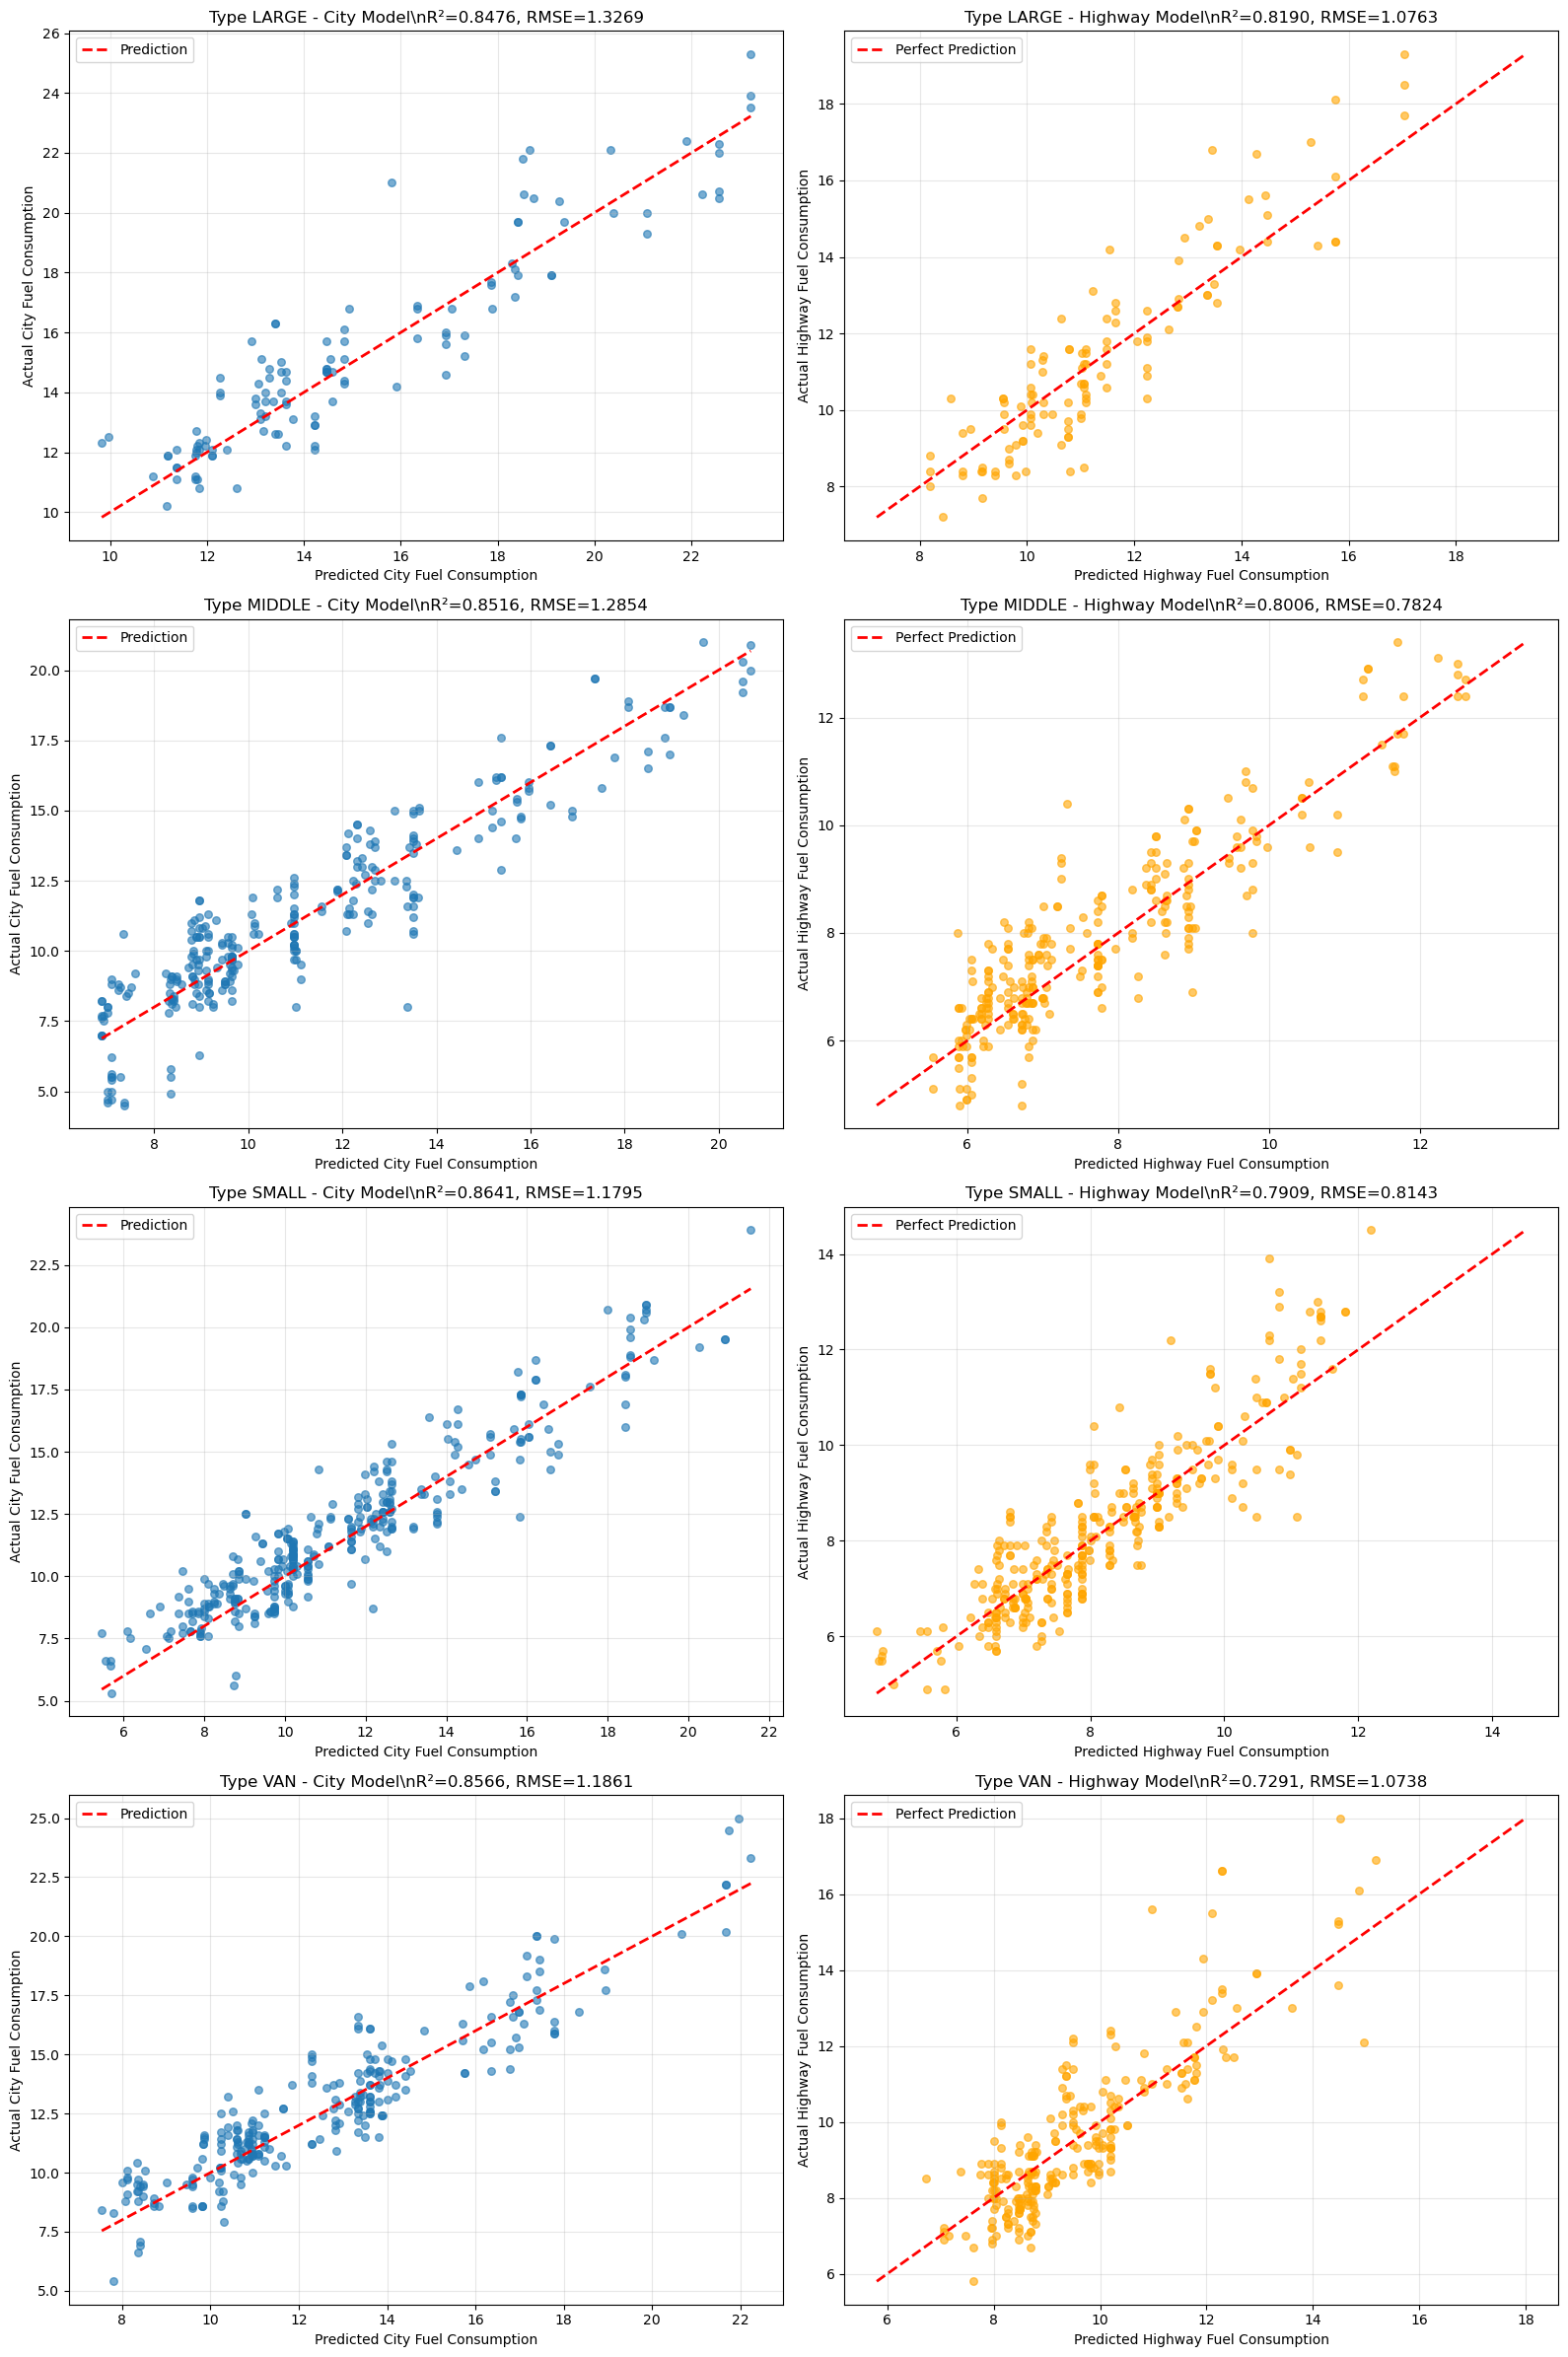

In [16]:
# Plot prediction vs actual for all vehicle types
if 'type_results' in locals() and len(type_results) > 0:
    fig, axes = plt.subplots(len(type_results), 2, figsize=(16, 6*len(type_results)))
    
    # Handle case where there's only one type
    if len(type_results) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (type_val, results) in enumerate(sorted(type_results.items())):
        # City model predictions
        ax1 = axes[idx, 0]
        y_test = results['city_test']
        y_pred = results['city_pred']
        
        ax1.scatter(y_pred, y_test, alpha=0.6, s=30)
        min_val = y_pred.min()
        max_val = y_pred.max()
        ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediction')
        ax1.set_xlabel('Predicted City Fuel Consumption')
        ax1.set_ylabel('Actual City Fuel Consumption')
        ax1.set_title(f'Type {type_val} - City Model\\nR²={results["city_r2"]:.4f}, RMSE={results["city_rmse"]:.4f}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Highway model predictions
        ax2 = axes[idx, 1]
        y_test = results['hwy_test']
        y_pred = results['hwy_pred']
        
        ax2.scatter(y_pred, y_test, alpha=0.6, s=30, color='orange')
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        ax2.set_xlabel('Predicted Highway Fuel Consumption')
        ax2.set_ylabel('Actual Highway Fuel Consumption')
        ax2.set_title(f'Type {type_val} - Highway Model\\nR²={results["hwy_r2"]:.4f}, RMSE={results["hwy_rmse"]:.4f}')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No results available. Please run the training cell first.")

#### Fuel-Efficient Cars by Vehicle Type (Below Prediction Line)
This section identifies cars with actual fuel consumption lower than predicted values, then ranks them by perpendicular distance from the prediction line $y=x$.

**Interpretation**
- A point below $y=x$ means: Actual < Predicted.
- For this notebook, that means the car is more fuel-efficient than the model expected.
- Larger distance below the line indicates stronger relative efficiency.

**Distance metric**
- Signed gap: $\Delta = \hat{y} - y$
- For below-line points, $\Delta > 0$.
- Perpendicular distance to $y=x$: $d = \frac{\Delta}{\sqrt{2}}$

The next code cell computes rankings for both city and highway models for each vehicle type.

In [ ]:
# Rank fuel-efficient cars (below prediction line) by vehicle type
top_n = 10  # change this if you want more/less rows per type

# Keep only identifier columns that exist in your dataset
id_cols_preferred = [ 'Transmission', 'Fuel Type','Engine Size(L)', 'Cylinders', 'Type']
id_cols = [c for c in id_cols_preferred if c in df.columns]

def build_efficiency_ranking(y_true, y_pred, target_label):
    ranking = pd.DataFrame({
        'row_index': y_true.index,
        'actual': np.asarray(y_true),
        'predicted': np.asarray(y_pred),
    })
    ranking['delta_pred_minus_actual'] = ranking['predicted'] - ranking['actual']
    ranking = ranking[ranking['delta_pred_minus_actual'] > 0].copy()
    ranking['distance_to_y_eq_x'] = ranking['delta_pred_minus_actual'] / np.sqrt(2)
    ranking = ranking.sort_values('distance_to_y_eq_x', ascending=False).reset_index(drop=True)
    ranking['rank'] = ranking.index + 1
    ranking['target'] = target_label
    return ranking

if 'type_results' in locals() and len(type_results) > 0:
    efficient_rankings = {}

    for type_val, results in sorted(type_results.items()):
        city_rank = build_efficiency_ranking(
            y_true=results['city_test'],
            y_pred=results['city_pred'],
            target_label='City'
        )
        hwy_rank = build_efficiency_ranking(
            y_true=results['hwy_test'],
            y_pred=results['hwy_pred'],
            target_label='Highway'
        )

        # Attach vehicle metadata from original dataframe when available
        if id_cols:
            city_meta = df.loc[city_rank['row_index'], id_cols].reset_index(drop=True)
            hwy_meta = df.loc[hwy_rank['row_index'], id_cols].reset_index(drop=True)
            city_rank = pd.concat([city_rank[['rank']], city_meta, city_rank.drop(columns=['rank'])], axis=1)
            hwy_rank = pd.concat([hwy_rank[['rank']], hwy_meta, hwy_rank.drop(columns=['rank'])], axis=1)

        efficient_rankings[type_val] = {
            'city': city_rank,
            'highway': hwy_rank
        }

    # Print top-N tables
    for type_val, tables in efficient_rankings.items():
        print("\n" + "=" * 110)
        print(f"TYPE {type_val} | TOP {top_n} MOST FUEL-EFFICIENT CARS (CITY)")
        print("=" * 110)
        print(tables['city'].head(top_n).to_string(index=False))

        print("\n" + "-" * 110)
        print(f"TYPE {type_val} | TOP {top_n} MOST FUEL-EFFICIENT CARS (HIGHWAY)")
        print("-" * 110)
        print(tables['highway'].head(top_n).to_string(index=False))

    print("\nSaved full rankings in variable: efficient_rankings")
    print("Access example: efficient_rankings['SMALL SUV']['city'].head(20)")
else:
    print("No results available. Please run the training cell first.")


TYPE LARGE | TOP 10 MOST FUEL-EFFICIENT CARS (CITY)
 rank  Engine Size(L)  Cylinders  Type  row_index  actual  predicted  delta_pred_minus_actual  distance_to_y_eq_x target
    1             5.3          8 LARGE       2741    14.6  16.931633                 2.331633            1.648714   City
    2             3.3          6 LARGE       4683    12.1  14.219680                 2.119680            1.498840   City
    3             5.6          8 LARGE       3249    15.2  17.317226                 2.117226            1.497105   City
    4             5.3          8 LARGE       1853    20.5  22.575874                 2.075874            1.467865   City
    5             3.3          6 LARGE       4132    12.2  14.219680                 2.019680            1.428129   City
    6             5.3          8 LARGE       2910    20.7  22.575874                 1.875874            1.326443   City
    7             2.5          4 LARGE        574    10.8  12.623377                 1.823377       

#### Training History by Vehicle Type
This block plots learning curves to inspect optimization behavior over epochs for each type and target.

**What this code does**
- Validates that `type_results` is available.
- Builds a subplot grid with one row per type and two panels: city and highway.
- Plots training loss and validation loss from stored histories.
- Applies labels, legends, and grid lines for readability.

**Why it matters**
- If training loss decreases but validation loss rises, this indicates overfitting.
- Parallel downward curves with small gaps suggest good generalization.
- Very flat curves can indicate underfitting or overly conservative learning rate settings.

**Expected outcome**
- Multi-panel learning-curve figure.
- Helpful diagnostics for deciding whether to retune architecture, regularization, or learning rate.

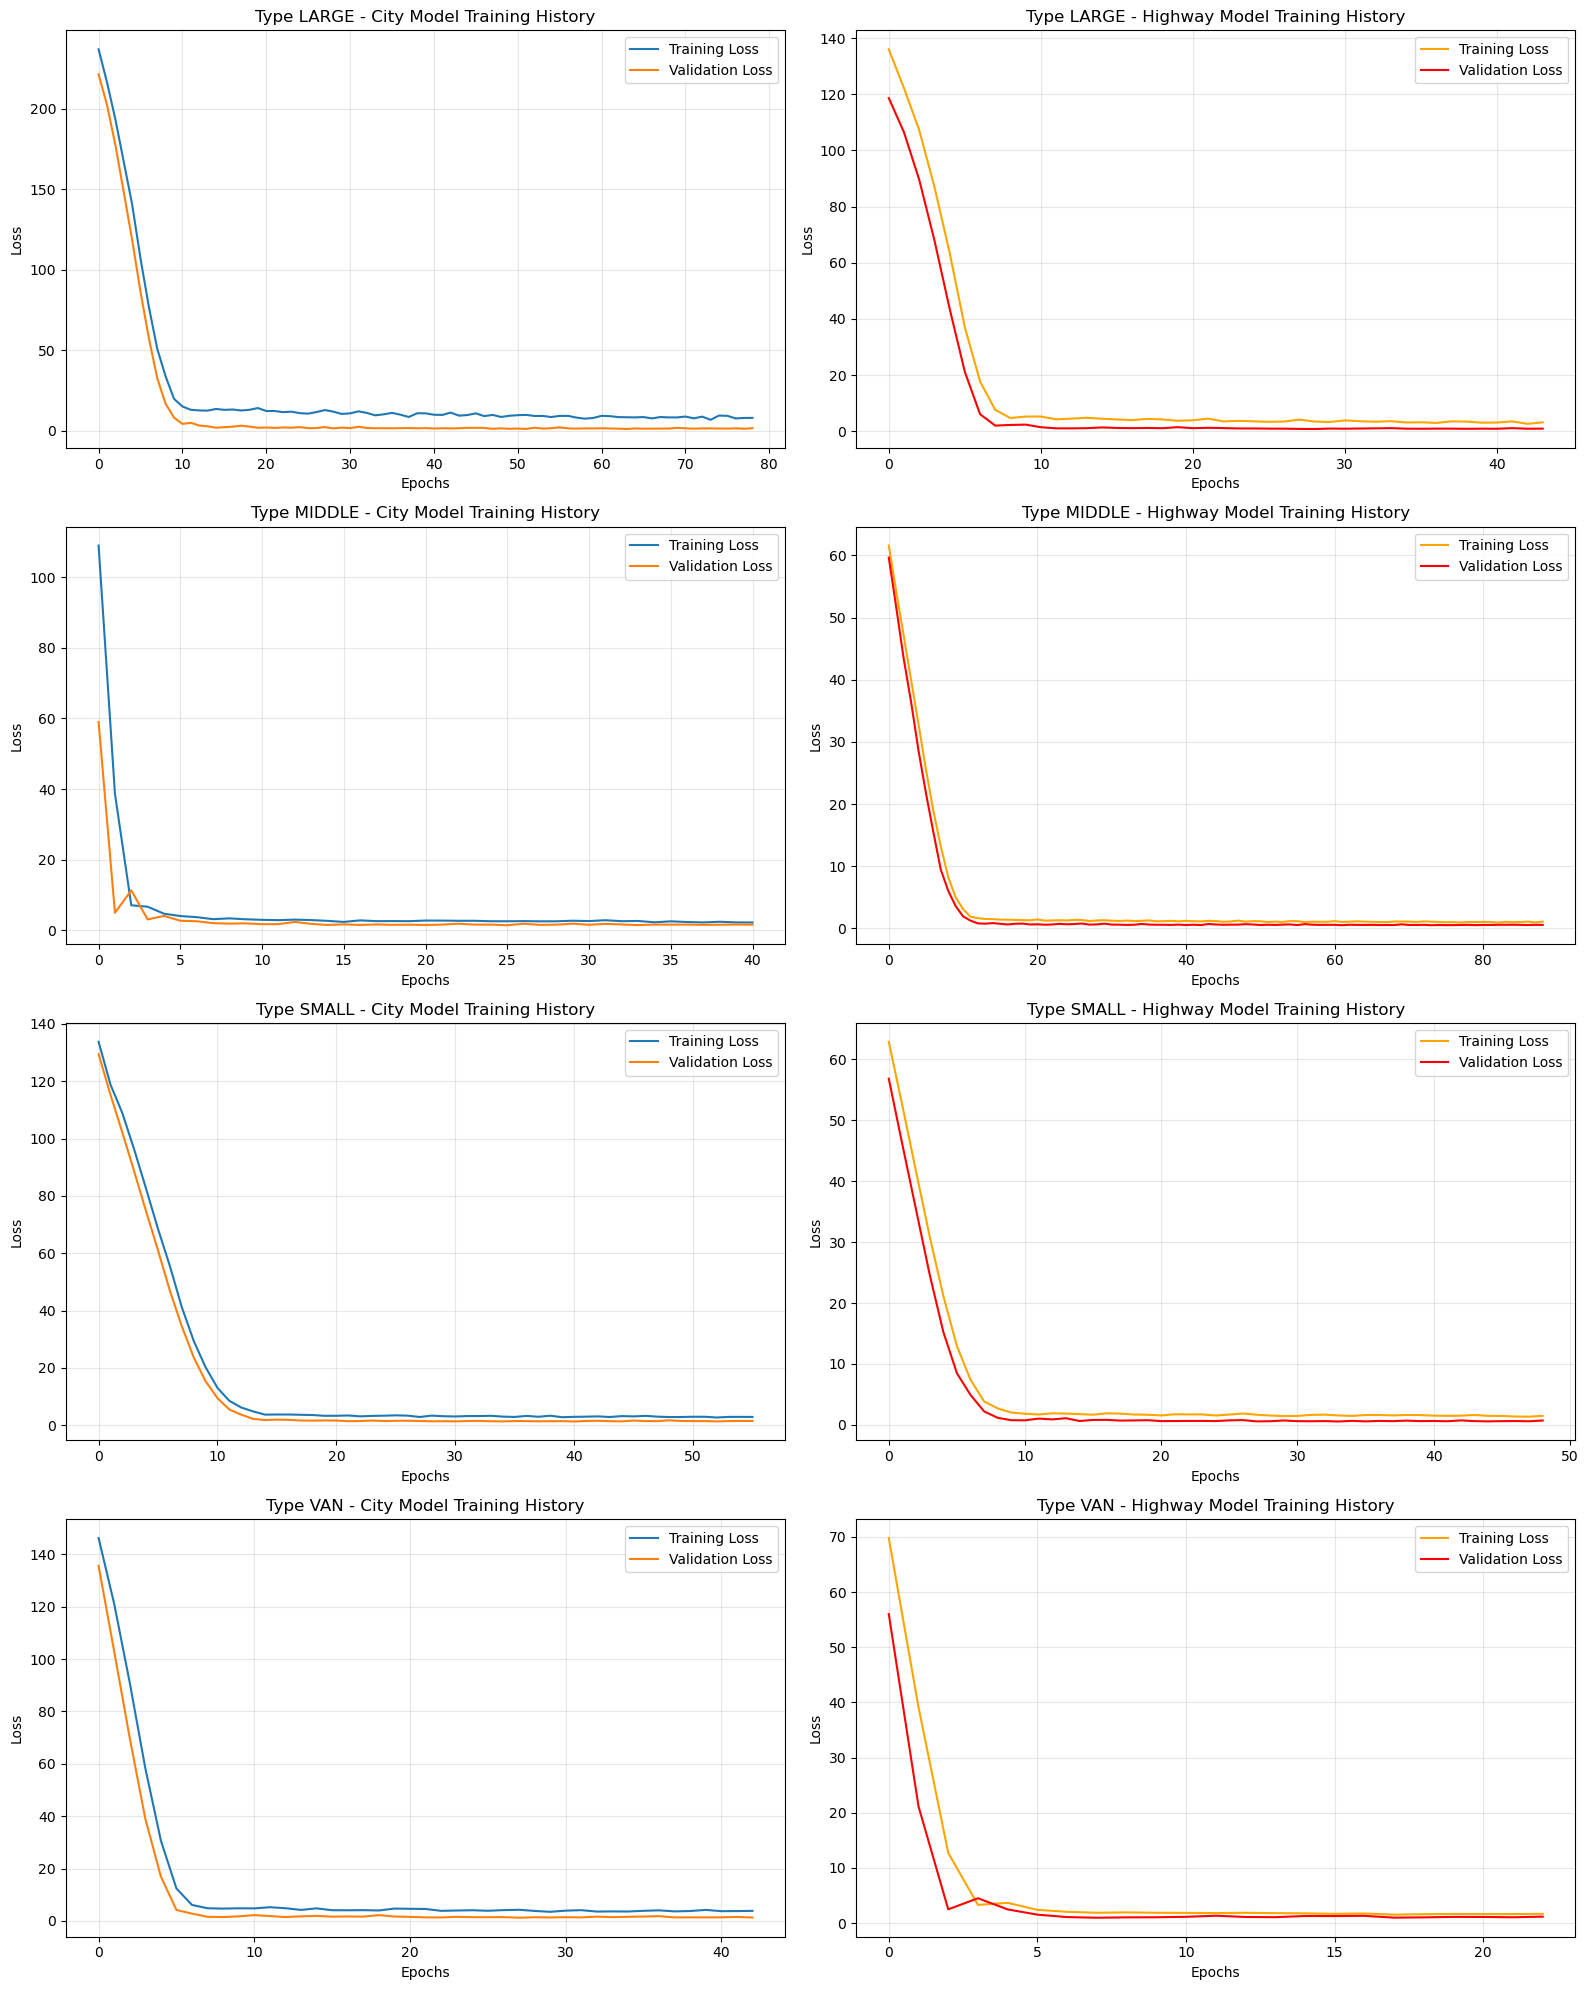

In [18]:
# Plot training history for all vehicle types
if 'type_results' in locals() and len(type_results) > 0:
    fig, axes = plt.subplots(len(type_results), 2, figsize=(16, 5*len(type_results)))
    
    # Handle case where there's only one type
    if len(type_results) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (type_val, results) in enumerate(sorted(type_results.items())):
        # City model training history
        ax1 = axes[idx, 0]
        ax1.plot(results['train_losses_city'], label='Training Loss')
        ax1.plot(results['val_losses_city'], label='Validation Loss')
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss')
        ax1.set_title(f'Type {type_val} - City Model Training History')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Highway model training history
        ax2 = axes[idx, 1]
        ax2.plot(results['train_losses_hwy'], label='Training Loss', color='orange')
        ax2.plot(results['val_losses_hwy'], label='Validation Loss', color='red')
        ax2.set_xlabel('Epochs')
        ax2.set_ylabel('Loss')
        ax2.set_title(f'Type {type_val} - Highway Model Training History')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No results available. Please run the training cell first.")

#### Performance Summary by Vehicle Type
This block compiles final model performance across all trained vehicle types into a concise tabular report.

**What this code does**
- Iterates through `type_results` and collects per-type metrics for both targets.
- Builds a summary DataFrame containing:
  - City/Highway $R^2$
  - City/Highway RMSE
  - Selected hidden-layer unit counts for each target
- Prints a formatted table to the console.
- Computes and prints average performance across all vehicle types.

**Why it matters**
- Provides a compact comparison view across segments.
- Makes it easy to identify strong/weak type-specific models.
- Average metrics give a quick global quality signal for this split-architecture strategy.

**Expected outcome**
- Console table with one row per vehicle type and aggregate averages at the end.

In [19]:
# Create comprehensive summary table
if 'type_results' in locals() and len(type_results) > 0:
    summary_data = []
    for type_val in sorted(type_results.keys()):
        results = type_results[type_val]
        summary_data.append({
            'Vehicle Type': type_val,
            'City R²': f"{results['city_r2']:.4f}",
            'City RMSE': f"{results['city_rmse']:.4f}",
            'Highway R²': f"{results['hwy_r2']:.4f}",
            'Highway RMSE': f"{results['hwy_rmse']:.4f}",
            'City Units (L1/L2)': f"{results['best_params_city']['n1']}/{results['best_params_city']['n2']}",
            'Highway Units (L1/L2)': f"{results['best_params_hwy']['n1']}/{results['best_params_hwy']['n2']}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\n" + "="*100)
    print("NEURAL NETWORK PERFORMANCE SUMMARY BY VEHICLE TYPE")
    print("="*100)
    print(summary_df.to_string(index=False))
    print("="*100)
    
    # Calculate average performance
    avg_city_r2 = np.mean([r['city_r2'] for r in type_results.values()])
    avg_city_rmse = np.mean([r['city_rmse'] for r in type_results.values()])
    avg_hwy_r2 = np.mean([r['hwy_r2'] for r in type_results.values()])
    avg_hwy_rmse = np.mean([r['hwy_rmse'] for r in type_results.values()])
    
    print(f"\nAverage Performance Across All Types:")
    print(f"  City - R²: {avg_city_r2:.4f}, RMSE: {avg_city_rmse:.4f}")
    print(f"  Highway - R²: {avg_hwy_r2:.4f}, RMSE: {avg_hwy_rmse:.4f}")
    print("="*100)
else:
    print("No results available. Please run the training cell first.")


NEURAL NETWORK PERFORMANCE SUMMARY BY VEHICLE TYPE
Vehicle Type City R² City RMSE Highway R² Highway RMSE City Units (L1/L2) Highway Units (L1/L2)
       LARGE  0.8476    1.3269     0.8190       1.0763              96/80                160/32
      MIDDLE  0.8516    1.2854     0.8006       0.7824             192/96                96/112
       SMALL  0.8641    1.1795     0.7909       0.8143             96/128               256/128
         VAN  0.8566    1.1861     0.7291       1.0738             192/80               192/128

Average Performance Across All Types:
  City - R²: 0.8550, RMSE: 1.2445
  Highway - R²: 0.7849, RMSE: 0.9367
